In [80]:
from auxiliary_functions import (
    fetch_profile, load_price_from_csv, load_technology_parameters, BETA_OBJ_DEFAULT)
from shipp.timeseries import TimeSeries
from shipp.components import Production, Storage
import math
import matplotlib.pyplot as plt
import numpy as np
from shipp.kernel_pyomo import solve_lp_pyomo_sizing
import time
import warnings
import numpy_financial as npf

# Case parameters
TOKEN = '96e53647b34ef4fb37b6958e9285eff9938ad7ce'
LAT, LON = 52.52, 4.90
DATE_FROM, DATE_TO = '2023-01-01', '2024-01-01'
COUNTRY = 'DNK'          # placeholder, using Danish parameters
PARAM_YEAR = 2025        # the only year in the CSV
N = 24 * 365                  
DT = 1.0
N_YEAR = 25
DISCOUNT_RATE = 0.03
P_MAX = 300.0
BETA_OBJ = BETA_OBJ_DEFAULT   # 1e-4, matches the kernel default

TECH_CSV = 'technology_parameters.csv'
PRICE_CSV = 'ember_prices.csv'

In [81]:
BUDGET = 800e6
BUDGET_TOL = 1e-3
I_MAX = BUDGET * (1 + BUDGET_TOL)
I_MIN = BUDGET * (1 - BUDGET_TOL)
# I_MAX = None
# I_MIN = None

In [82]:
# Per-unit profiles
wind_ts = fetch_profile('wind', LAT, LON, DATE_FROM, DATE_TO, TOKEN,
                        height=90, turbine='Vestas V150 4500')
pv_ts = fetch_profile('pv', LAT, LON, DATE_FROM, DATE_TO, TOKEN,
                      tilt=35, azim=180)
price_ts = load_price_from_csv('NLD', 2023, PRICE_CSV)

# Slice to the case horizon
wind_ts = type(wind_ts)(wind_ts.data[:N], DT)
pv_ts = type(pv_ts)(pv_ts.data[:N], DT)
price_ts = type(price_ts)(price_ts.data[:N], DT)

# Technology parameters
params = load_technology_parameters(TECH_CSV, COUNTRY, PARAM_YEAR)

In [83]:
# Pre-annualization: CAPEX is multiplied by n_year / lifetime so the
# kernel sees the project-horizon cost.
wind_life = params[('wind', 'lifetime')]
pv_life = params[('pv', 'lifetime')]
lfp_life = params[('lfp', 'lifetime')]

wind = Production(power_ts=wind_ts,
                  p_cost=params[('wind','capex')] * N_YEAR / wind_life,
                  p_max=None,
                  p_max_is_decision=True,
                  opex_fix=params[('wind','opex')],
                  opex_var=0.0)

pv   = Production(power_ts=pv_ts,
                  p_cost=params[('pv','capex')] * N_YEAR / pv_life,
                  p_max=None,
                  p_max_is_decision=True,
                  opex_fix=params[('pv','opex')],
                  opex_var=0.0)

# LFP storage: round-trip AC efficiency, split symmetrically.
eff_rt = params[('lfp', 'eff_rt_ac')]
eff_half = math.sqrt(eff_rt)

lfp = Storage(
    e_cap=None,
    p_cap=None,
    eff_in=eff_half,
    eff_out=eff_half,
    p_cost=0.0,
    e_cost=params[('lfp', 'capex')] * N_YEAR / lfp_life,
    soc_min=0.0,
    soc_max=1.0,
    lifetime=int(lfp_life),
    opex_fix=0.0,
    opex_var=0.0,
    duration=params[('lfp', 'duration')])

# Null second slots (kernel requires two of each).
null_prod = Production(power_ts=TimeSeries([0.0] * N, DT),
                       p_cost=1.0, p_max=0.0)
null_stor = Storage(e_cap=0, p_cap=0, eff_in=1.0, eff_out=1.0,
                    p_cost=0.0, e_cost=0.0, duration=1.0)
null_stor2 = Storage(e_cap=0, p_cap=0, eff_in=1.0, eff_out=1.0,
                    p_cost=0.0, e_cost=0.0, duration=1.0)

In [84]:
t0 = time.perf_counter()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    os_result = solve_lp_pyomo_sizing(
        price_ts=price_ts,
        prod1=wind, prod2=pv,
        prof1_unit=wind_ts, prof2_unit=pv_ts,
        stor1=lfp, stor2=null_stor,
        discount_rate=DISCOUNT_RATE, n_year=N_YEAR,
        p_max=P_MAX, n=N,
        i_max=I_MAX, i_min=I_MIN,
        beta_obj=BETA_OBJ,
        options=dict(name_solver='gurobi'))
t1 = time.perf_counter()

print(f"Wall-clock solve time: {t1 - t0:.2f} s")
if caught:
    print("Warnings raised during solve:")
    for w in caught:
        print(f"  [{w.category.__name__}] {w.message}")
else:
    print("No warnings raised during solve.")

Failed error check
Error : 4.35e+00	1.00e-14
Error : 0.00e+00	0.00e+00
Wall-clock solve time: 11.70 s
Warnings raised during solve:
  [RuntimeWarning] Failed error check in solve_lp_pyomo_sizing


In [85]:
# --- Extract quantities ---
x_wind = os_result.production_list[0].p_max
x_pv = os_result.production_list[1].p_max
p_stor = os_result.storage_list[0].p_cap
e_stor = os_result.storage_list[0].e_cap

raw_prod_hourly = wind_ts.data * x_wind + pv_ts.data * x_pv
raw_prod_total = raw_prod_hourly.sum()
delivered_total = os_result.power_out.data.sum()
curtailed_total = raw_prod_hourly.sum() - (
    os_result.production_p[0].data.sum() + os_result.production_p[1].data.sum())
losses_total = sum(l.sum() for l in os_result.losses)

charge_total = -np.minimum(os_result.storage_p[0].data, 0).sum()
discharge_total = np.maximum(os_result.storage_p[0].data, 0).sum()

soc = os_result.storage_e[0].data

hours_at_pmax = int(np.sum(np.isclose(os_result.power_out.data, P_MAX, atol=1e-3)))

# --- Economics breakdown ---
# CAPEX (effective, pre-annualized, as the kernel sees it)
capex_wind = wind.p_cost * x_wind
capex_pv = pv.p_cost * x_pv
capex_stor_p = lfp.p_cost * p_stor
capex_stor_e = lfp.e_cost * e_stor
capex_total = capex_wind + capex_pv + capex_stor_p + capex_stor_e

# CAPEX (nominal, what you'd actually spend)
capex_wind_nom = params[('wind', 'capex')] * x_wind
capex_pv_nom = params[('pv', 'capex')] * x_pv
capex_stor_nom = params[('lfp', 'capex')] * e_stor    # LFP is energy-based
capex_total_nom = capex_wind_nom + capex_pv_nom + capex_stor_nom

# Fixed OPEX (annual, kernel scales by factor internally)
opex_fix_wind = wind.opex_fix * x_wind
opex_fix_pv = pv.opex_fix * x_pv
opex_fix_total = opex_fix_wind + opex_fix_pv

# The discounted sum used by the kernel in the objective
factor = npf.npv(DISCOUNT_RATE, np.ones(N_YEAR)) - 1
opex_fix_pv_total = factor * opex_fix_total

# Revenue and curtailment-penalty contributions (as seen in the objective)
factor_annual = 365 * 24 / N * factor
revenue_obj = factor_annual * (price_ts.data * os_result.power_out.data).sum()
curtail_penalty_obj = BETA_OBJ * factor_annual * curtailed_total

# --- Print summary ---
print("=" * 62)
print("Installed capacities")
print("=" * 62)
print(f"  Wind             {x_wind:>10.3f} MW")
print(f"  PV               {x_pv:>10.3f} MW")
print(f"  LFP storage      {p_stor:>10.3f} MW  /  {e_stor:.3f} MWh")
print()

print("=" * 62)
print("Dispatch (over {} h)".format(N))
print("=" * 62)
print(f"  Raw production   {raw_prod_total:>12,.1f} MWh  "
      f"(mean {raw_prod_total/N:.2f} MW, peak {raw_prod_hourly.max():.2f} MW)")
print(f"  Delivered        {delivered_total:>12,.1f} MWh  "
      f"(mean {delivered_total/N:.2f} MW, peak {os_result.power_out.data.max():.2f} MW)")
print(f"  Curtailed        {curtailed_total:>12,.1f} MWh  "
      f"({100*curtailed_total/raw_prod_total:.2f}% of raw)")
print(f"  Storage losses   {losses_total:>12,.1f} MWh")
print(f"  Charge           {charge_total:>12,.1f} MWh")
print(f"  Discharge        {discharge_total:>12,.1f} MWh")
if charge_total > 0:
    print(f"  Realized RTE     {100*discharge_total/charge_total:>11.2f}%  "
          f"(nominal {100*eff_rt:.2f}%)")
print(f"  SoC              min {soc.min():.2f}  mean {soc.mean():.2f}  max {soc.max():.2f} MWh")
print(f"  Hours at p_max   {hours_at_pmax:>12,d} h  "
      f"({100*hours_at_pmax/N:.1f}% of year)")
print()

print("=" * 62)
print("CAPEX (nominal, what you spend)")
print("=" * 62)
print(f"  Wind             {capex_wind_nom * 1e-6:>10.3f} M EUR  "
      f"({x_wind:.3f} MW x {params[('wind', 'capex')]*1e-6:.3f} M/MW)")
print(f"  PV               {capex_pv_nom * 1e-6:>10.3f} M EUR  "
      f"({x_pv:.3f} MW x {params[('pv', 'capex')]*1e-6:.3f} M/MW)")
print(f"  LFP storage      {capex_stor_nom * 1e-6:>10.3f} M EUR  "
      f"({e_stor:.3f} MWh x {params[('lfp', 'capex')]*1e-6:.3f} M/MWh)")
print(f"  {'─' * 58}")
print(f"  Total            {capex_total_nom * 1e-6:>10.3f} M EUR")
if 'BUDGET' in globals():
    remaining = BUDGET - capex_total_nom
    print(f"  Budget           {BUDGET * 1e-6:>10.3f} M EUR  "
          f"(remaining {remaining * 1e-6:+.3f} M, "
          f"{100*capex_total_nom/BUDGET:.2f}% used)")
print()

print("=" * 62)
print("CAPEX (effective, pre-annualized, as the kernel sees it)")
print("=" * 62)
print(f"  Wind             {capex_wind * 1e-6:>10.3f} M EUR")
print(f"  PV               {capex_pv * 1e-6:>10.3f} M EUR")
print(f"  LFP p            {capex_stor_p * 1e-6:>10.3f} M EUR")
print(f"  LFP e            {capex_stor_e * 1e-6:>10.3f} M EUR")
print(f"  {'─' * 58}")
print(f"  Total            {capex_total * 1e-6:>10.3f} M EUR")
print()

print("=" * 62)
print("OPEX (fixed, annual)")
print("=" * 62)
print(f"  Wind             {opex_fix_wind:>12,.0f} EUR/y  "
      f"({x_wind:.3f} MW x {wind.opex_fix:,.0f} EUR/MW/y)")
print(f"  PV               {opex_fix_pv:>12,.0f} EUR/y  "
      f"({x_pv:.3f} MW x {pv.opex_fix:,.0f} EUR/MW/y)")
print(f"  {'─' * 58}")
print(f"  Total            {opex_fix_total:>12,.0f} EUR/y")
print(f"  Discounted       {opex_fix_pv_total * 1e-6:>12,.3f} M EUR  "
      f"(x {factor:.3f} over {N_YEAR} y)")
print()

print("=" * 62)
print("Economics")
print("=" * 62)
print(f"  Revenue (actual)       {os_result.revenue * 1e-6:>10.3f} M EUR")
print(f"  Revenue (objective)    {revenue_obj * 1e-6:>10.3f} M EUR  "
      f"(x {factor_annual:.4f})")
print(f"  Curtailment penalty    {curtail_penalty_obj * 1e-6:>10.6f} M EUR")
print(f"  Objective NPV          {os_result.npv_objective:>10.3f} M")
print(f"  Legacy NPV (os.npv)    {os_result.npv:>10.3f} M")
print()

# --- Objective reconciliation ---
# The objective is: factor_annual * sum((price + beta) * power_out)
#                  - factor * opex_fix_total
#                  - capex_total (effective)
print("=" * 62)
print("Objective reconciliation")
print("=" * 62)
recon = (revenue_obj + curtail_penalty_obj
         - opex_fix_pv_total
         - capex_total)
print(f"  Revenue                {revenue_obj * 1e-6:>10.3f} M")
print(f"  Curtailment penalty    {curtail_penalty_obj * 1e-6:>10.6f} M")
print(f"  − OPEX (discounted)    {-opex_fix_pv_total * 1e-6:>10.3f} M")
print(f"  − CAPEX (effective)    {-capex_total * 1e-6:>10.3f} M")
print(f"  {'─' * 58}")
print(f"  Sum                    {recon * 1e-6:>10.3f} M")
print(f"  Kernel (npv_objective) {os_result.npv_objective:>10.3f} M")
recon_gap = abs(recon * 1e-6 - os_result.npv_objective)
print(f"  Gap                    {recon_gap:>10.6e} M")
print()

print("=" * 62)
print("Physical checks")
print("=" * 62)
print(f"  Loss check             {os_result.check_losses(1e-4)}")

energy_residual = raw_prod_total - delivered_total - curtailed_total - losses_total
print(f"  Energy balance         residual = {energy_residual:.6e} MWh")
assert abs(energy_residual) < 1e-3 * max(raw_prod_total, 1.0), \
    f"Energy balance off by {energy_residual}"

A_opt = wind_ts.data * x_wind + pv_ts.data * x_pv
headroom = np.maximum(P_MAX - A_opt, 0.0)
net_stor = os_result.storage_p[0].data + os_result.storage_p[1].data
headroom_violation = float((net_stor - headroom).max())
print(f"  Storage headroom       margin = {abs(headroom_violation):.3e} MW  "
      f"({'OK' if headroom_violation < 1e-6 else 'VIOLATED'})")

print()
print("=" * 62)
print("Solver")
print("=" * 62)
print(f"  Wall-clock (total)     {t1 - t0:>10.2f} s")
print(f"  Wallclock (solver)     {getattr(os_result, 'time', None)}")

Installed capacities
  Wind                649.382 MW
  PV                  232.089 MW
  LFP storage           4.560 MW  /  9.121 MWh

Dispatch (over 8760 h)
  Raw production    3,088,399.2 MWh  (mean 352.56 MW, peak 783.18 MW)
  Delivered         2,167,373.1 MWh  (mean 247.42 MW, peak 300.00 MW)
  Curtailed           911,235.8 MWh  (29.51% of raw)
  Storage losses        9,790.3 MWh
  Charge               13,103.6 MWh
  Discharge             3,313.3 MWh
  Realized RTE           25.29%  (nominal 91.00%)
  SoC              min 0.00  mean 1.86  max 9.12 MWh
  Hours at p_max          5,140 h  (58.7% of year)

CAPEX (nominal, what you spend)
  Wind                766.271 M EUR  (649.382 MW x 1.180 M/MW)
  PV                  139.253 M EUR  (232.089 MW x 0.600 M/MW)
  LFP storage           2.554 M EUR  (9.121 MWh x 0.280 M/MWh)
  ──────────────────────────────────────────────────────────
  Total               908.078 M EUR
  Budget              800.000 M EUR  (remaining -108.078 M, 113.51% 

In [86]:
AGGREGATE_THRESHOLD = 24 * 30  # one month in hours


def _aggregate(t, arr, dt, mode='mean'):
    """Aggregate a 1-D array to daily resolution when its length exceeds
    AGGREGATE_THRESHOLD hours.

    mode = 'mean' for prices and SoC; 'sum' for power (gives energy per day);
    for stacked power plots, use 'sum' so the daily total remains meaningful.

    Returns (t_agg, arr_agg, dt_agg, is_daily).
    """
    n = len(arr)
    if n <= AGGREGATE_THRESHOLD:
        return t, arr, dt, False
    n_days = n // 24
    trimmed = arr[:n_days * 24].reshape(n_days, 24)
    if mode == 'sum':
        arr_agg = trimmed.sum(axis=1)
    else:
        arr_agg = trimmed.mean(axis=1)
    t_agg = np.arange(n_days)
    return t_agg, arr_agg, 1.0, True

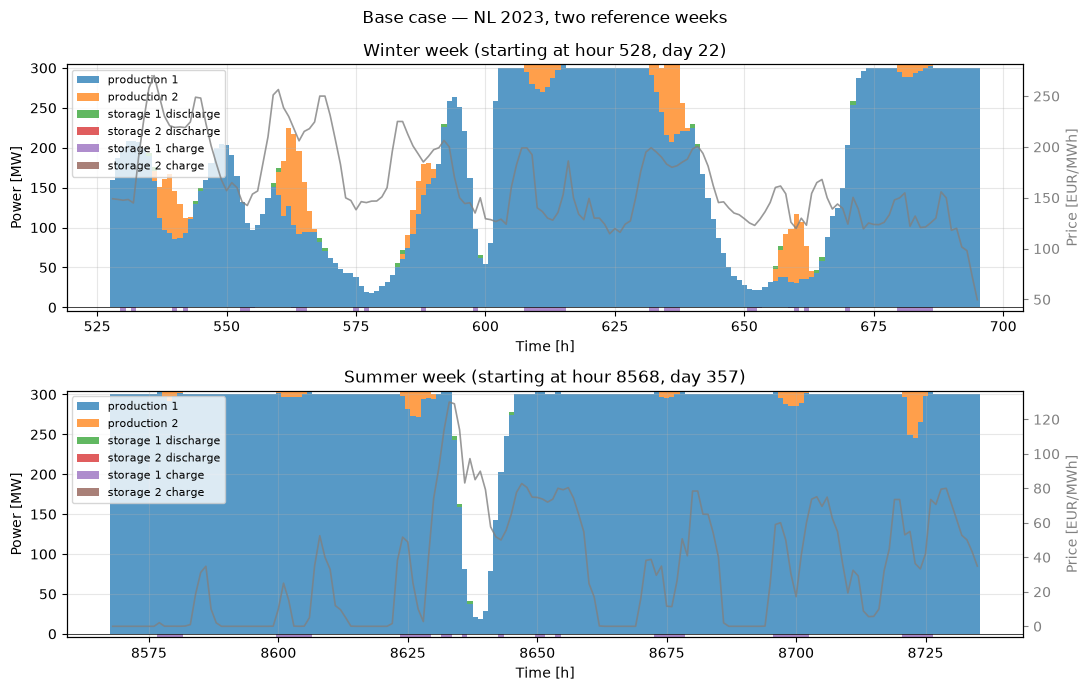

In [87]:
def plot_schedule_two_weeks(os_, price, week_winter_start, week_summer_start,
                            title=""):
    """Plot stacked generation + storage bars over two reference weeks,
    with price on the twin axis.

    week_winter_start, week_summer_start: hour indices into the timeseries,
    each the start of a 168-hour window. If None, they're chosen
    automatically (min and max mean daily temperature proxy = mean price).
    """
    dt = os_.power_out.dt
    n = len(os_.power_out.data)

    # Choose reference weeks if not given: pick the 7-day windows with
    # lowest and highest mean price.
    if week_winter_start is None or week_summer_start is None:
        n_days = n // 24
        daily_mean_price = np.asarray(price[:n_days * 24]).reshape(n_days, 24).mean(axis=1)
        idx_min = int(np.argmin(daily_mean_price)) * 24
        idx_max = int(np.argmax(daily_mean_price)) * 24
        # Ensure the two weeks don't overlap
        if abs(idx_min - idx_max) < 24 * 7:
            idx_max = (idx_min + 24 * 14) % (n_days * 24)
        week_winter_start = min(idx_min, idx_max)
        week_summer_start = max(idx_min, idx_max)

    windows = [
        ("Winter week", week_winter_start),
        ("Summer week", week_summer_start),
    ]

    prod = [p.data[:n] for p in os_.production_p]
    stor = [s.data[:n] for s in os_.storage_p]
    price_arr = np.asarray(price)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7))
    for ax, (label, start) in zip(axes, windows):
        end = start + 24 * 7
        t = np.arange(start, end) * dt
        window_slice = slice(start, end)

        # Positive stacking
        bottom_pos = np.zeros(end - start)
        for i, p in enumerate(prod):
            vals = p[window_slice]
            ax.bar(t, vals, width=dt, bottom=bottom_pos,
                   label=f"production {i+1}", alpha=0.75)
            bottom_pos = bottom_pos + vals
        for i, s in enumerate(stor):
            pos = np.maximum(s[window_slice], 0)
            ax.bar(t, pos, width=dt, bottom=bottom_pos,
                   label=f"storage {i+1} discharge", alpha=0.75)
            bottom_pos = bottom_pos + pos

        # Negative stacking
        bottom_neg = np.zeros(end - start)
        for i, s in enumerate(stor):
            neg = np.minimum(s[window_slice], 0)
            ax.bar(t, neg, width=dt, bottom=bottom_neg,
                   label=f"storage {i+1} charge", alpha=0.75)
            bottom_neg = bottom_neg + neg

        ax.axhline(0, color="k", lw=0.5)
        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Power [MW]")
        ax.set_title(f"{label} (starting at hour {start}, day {start//24})")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(alpha=0.3)

        ax2 = ax.twinx()
        ax2.plot(t, price_arr[window_slice], color="grey", lw=1.2,
                 alpha=0.8, label="price")
        ax2.set_ylabel("Price [EUR/MWh]", color="grey")
        ax2.tick_params(axis="y", colors="grey")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_schedule_two_weeks(os_result, price_ts.data,
                        week_winter_start=None, week_summer_start=None,
                        title="Base case — NL 2023, two reference weeks")

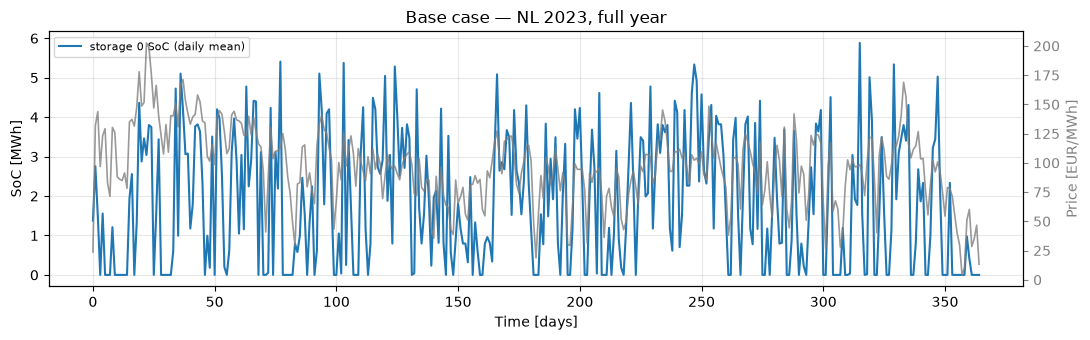

In [88]:
def plot_soc(os_, price, title=""):
    """Plot storage state-of-charge with price on the twin axis.

    When n > AGGREGATE_THRESHOLD, both series are averaged to daily resolution.
    Mean SoC is meaningful; max SoC per day would lose the intra-day shape.
    """
    dt = os_.storage_e[0].dt
    n = len(os_.storage_e[0].data)
    t = np.arange(n) * dt

    price_arr = np.asarray(price)

    _, price_agg, _, is_daily = _aggregate(t, price_arr[:n], dt, mode='mean')

    fig, ax = plt.subplots(figsize=(11, 3.5))

    for i, e in enumerate(os_.storage_e):
        if np.any(e.data):
            t_agg, soc_agg, dt_agg, _ = _aggregate(t, e.data, dt, mode='mean')
            ax.plot(t_agg, soc_agg, label=f"storage {i} SoC"
                    + (" (daily mean)" if is_daily else ""))

    ax.set_xlabel("Time [days]" if is_daily else "Time [h]")
    ax.set_ylabel("SoC [MWh]")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(t_agg if is_daily else t, price_agg, color="grey",
             lw=1.2, alpha=0.8, label="price")
    ax2.set_ylabel("Price [EUR/MWh]", color="grey")
    ax2.tick_params(axis="y", colors="grey")

    fig.tight_layout()
    plt.show()

plot_soc(os_result, price_ts.data,
         title="Base case — NL 2023, full year")